# Лабораторная Работа 5
## Лабораторную работу сделал Варов Всеволод, 4 вариант, студент группы 6202-090301D

## Пункт 0.
Импорт пакетов, инициализация полезных функций

### Импорт пакетов

In [123]:
from numpy import ravel, arange
from pandas import DataFrame
from keras.utils import to_categorical
from keras.layers import Dense, Input, Dropout, LeakyReLU
from keras.models import Sequential
from keras.metrics import (
    categorical_accuracy, 
    Precision,
    Recall,
    TruePositives,
    FalsePositives)
from keras.activations import softmax
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import plot, legend
from scikitplot.metrics import plot_confusion_matrix, plot_roc_curve

### Вспомогательные функции

In [124]:
def f1(prec, recall) -> float:
    return (2 * prec * recall) / (prec + recall)


def create_model(
        *layers,
        optimizer: str = None,
        loss: str = None,
        metrics: list = None) -> Sequential:
    m = Sequential(layers)
    m.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return m

In [125]:
def train_dependency(model: Sequential, data, targets) -> DataFrame:
    out = []

    for f in arange(0.1, 1.0, step=0.1):

        train_x, test_x, train_y, test_y = train_test_split(
            data,
            targets,
            train_size=f,
            random_state=0)
        scalar = StandardScaler()
        scalar.fit(train_x)
        train_x, test_x = scalar.transform(train_x), scalar.transform(test_x)
        train_y, test_y = to_categorical(train_y, 3), to_categorical(test_y, 3)

        model.fit(test_x, test_y, epochs=40)
        test = model.evaluate(test_x, test_y)

        model.fit(train_x, train_y, epochs=40)
        train = model.evaluate(train_x, train_y)

        out.append(test[:2] + train[:2])

    return DataFrame(data=out, columns=("test_loss", "test_accuracy", "train_loss", "train_accuracy"))


def epoch_dependency(model: Sequential, epochs: int, test_x, test_y, train_x, train_y) -> DataFrame:
    out = []

    for i in range(epochs):
        
        model.fit(test_x, test_y, epochs=i)
        test = model.evaluate(test_x, test_y)

        model.fit(train_x, train_y, epochs=i)
        train = model.evaluate(train_x, train_y)

        out.append(test[:2] + train[:2])

    return DataFrame(data=out, columns=("test_loss", "test_accuracy", "train_loss", "train_accuracy"))


def dropout_dependency(dropout_factory: callable, test_x, test_y, train_x, train_y) -> DataFrame:
    out = []

    for d in arange(0.2, 0.5, step=0.1):
        model = dropout_factory(d)

        model.fit(test_x, test_y, epochs=40)
        test = model.evaluate(test_x, test_y)

        model.fit(train_x, train_y, epochs=40)
        train = model.evaluate(train_x, train_y)

        out.append(test[:2] + train[:2])

    return DataFrame(data=out, columns=("test_loss", "test_accuracy", "train_loss", "train_accuracy"))


### Константы

In [126]:
MET = (categorical_accuracy, Precision(), Recall(), TruePositives(), FalsePositives())
ACT = LeakyReLU()
OPT0 = "adadelta"
OPT1 = "adamax"
LOSS_FUNCTION = "mean_absolute_error"

## Пункт 1.
Считать файл с данными для классификации итальянских вин (модуль `sklearn.datasets`)

In [127]:
wines = load_wine()
data = wines.data
targets = ravel(wines.target)

Разбиение на обучающие и тренировочные выборки

In [128]:
train_x, test_x, train_y, test_y = train_test_split(
    data,
    targets,
    test_size=0.20,
    random_state=0)

Приминение ScalarTransform и to_categorial

In [129]:
scalar = StandardScaler()
scalar.fit(train_x)
train_x, test_x = scalar.transform(train_x), scalar.transform(test_x)
train_y, test_y = train_y, test_y = to_categorical(train_y, 3), to_categorical(test_y, 3)

## Пункт 2.
Написать программу, имитирующую работу многослойного персептрона с настраиваемым числом скрытых слоёв от 1 до 3 в соответствии с вариантом

In [130]:
def adadelta_low() -> Sequential:
    return create_model(
            Input(13),
            Dense(40, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT0,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adamax_low() -> Sequential:
    return create_model(
            Input(13),
            Dense(40, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT1,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adadelta_high() -> Sequential:
    return create_model(
            Input(13),
            Dense(40, activation=ACT),
            Dense(80, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT0,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adamax_high() -> Sequential:
    return create_model(
            Input(13),
            Dense(40, activation=ACT),
            Dense(80, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT1,
            loss=LOSS_FUNCTION,
            metrics=MET)

### Создаем тестовые модели

In [131]:
DELTA1 = adadelta_low()
DELTA2 = adadelta_high()
MAX1 = adamax_low()
MAX2 = adamax_high()

## Пункт 3.
    Провести обучение сети с использованием заданных алгоритмов обучения

Adadelta с одним скрытым слоем

In [171]:
sgd_low_history = DELTA1.fit(train_x, train_y, epochs=40)

Epoch 1/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3912 - categorical_accuracy: 0.4930 - precision_4: 0.5357 - recall_4: 0.2113 - true_positives_4: 30.0000 - false_positives_4: 26.0000
Epoch 2/100
5/5 [==============================] - 0s 3ms/step - loss: 0.3912 - categorical_accuracy: 0.4930 - precision_4: 0.5357 - recall_4: 0.2113 - true_positives_4: 30.0000 - false_positives_4: 26.0000
Epoch 3/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3911 - categorical_accuracy: 0.4930 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 4/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3911 - categorical_accuracy: 0.4930 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 5/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3910 - categorical_accuracy: 0.4930 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31

5/5 [==============================] - 0s 3ms/step - loss: 0.3889 - categorical_accuracy: 0.5070 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 41/100
5/5 [==============================] - 0s 3ms/step - loss: 0.3889 - categorical_accuracy: 0.5070 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 42/100
5/5 [==============================] - 0s 3ms/step - loss: 0.3888 - categorical_accuracy: 0.5070 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 43/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3888 - categorical_accuracy: 0.5070 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 44/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3887 - categorical_accuracy: 0.5070 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - 

5/5 [==============================] - 0s 2ms/step - loss: 0.3865 - categorical_accuracy: 0.5141 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 80/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3865 - categorical_accuracy: 0.5141 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 81/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3864 - categorical_accuracy: 0.5141 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 82/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3863 - categorical_accuracy: 0.5141 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 26.0000
Epoch 83/100
5/5 [==============================] - 0s 2ms/step - loss: 0.3863 - categorical_accuracy: 0.5141 - precision_4: 0.5439 - recall_4: 0.2183 - true_positives_4: 31.0000 - 

Adamax с одним скрытым слоем

In [133]:
nadam_low_history = MAX1.fit(train_x, train_y, epochs=23)

Epoch 1/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4903 - categorical_accuracy: 0.1479 - precision_4: 0.2868 - recall_4: 0.1373 - true_positives_4: 39.0000 - false_positives_4: 97.0000
Epoch 2/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4702 - categorical_accuracy: 0.2042 - precision_4: 0.1944 - recall_4: 0.0986 - true_positives_4: 14.0000 - false_positives_4: 58.0000
Epoch 3/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4516 - categorical_accuracy: 0.2676 - precision_4: 0.2639 - recall_4: 0.1338 - true_positives_4: 19.0000 - false_positives_4: 53.0000
Epoch 4/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4327 - categorical_accuracy: 0.3662 - precision_4: 0.3768 - recall_4: 0.1831 - true_positives_4: 26.0000 - false_positives_4: 43.0000
Epoch 5/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4144 - categorical_accuracy: 0.4155 - precision_4: 0.4776 - recall_4: 0.2254 - true_positives_4: 32.0000

5/5 [==============================] - 0s 2ms/step - loss: 0.0838 - categorical_accuracy: 0.9718 - precision_4: 0.9787 - recall_4: 0.9718 - true_positives_4: 138.0000 - false_positives_4: 3.0000


Adadelta с двумя скрытыми слоями

In [134]:
nadam_low_history = DELTA2.fit(train_x, train_y, epochs=40)

Epoch 1/40
5/5 [==============================] - 1s 2ms/step - loss: 0.4265 - categorical_accuracy: 0.3310 - precision_4: 0.8256 - recall_4: 0.5669 - true_positives_4: 161.0000 - false_positives_4: 34.0000
Epoch 2/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4264 - categorical_accuracy: 0.3310 - precision_4: 0.4259 - recall_4: 0.1620 - true_positives_4: 23.0000 - false_positives_4: 31.0000
Epoch 3/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4263 - categorical_accuracy: 0.3310 - precision_4: 0.4259 - recall_4: 0.1620 - true_positives_4: 23.0000 - false_positives_4: 31.0000
Epoch 4/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4262 - categorical_accuracy: 0.3310 - precision_4: 0.4259 - recall_4: 0.1620 - true_positives_4: 23.0000 - false_positives_4: 31.0000
Epoch 5/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4261 - categorical_accuracy: 0.3310 - precision_4: 0.4259 - recall_4: 0.1620 - true_positives_4: 23.000

5/5 [==============================] - 0s 3ms/step - loss: 0.4227 - categorical_accuracy: 0.3451 - precision_4: 0.4423 - recall_4: 0.1620 - true_positives_4: 23.0000 - false_positives_4: 29.0000


Adamax с двумя скрытыми слоями

In [135]:
nadam_low_history = MAX2.fit(train_x, train_y, epochs=15)

Epoch 1/80
5/5 [==============================] - 1s 2ms/step - loss: 0.4557 - categorical_accuracy: 0.2254 - precision_4: 0.3067 - recall_4: 0.0810 - true_positives_4: 23.0000 - false_positives_4: 52.0000
Epoch 2/80
5/5 [==============================] - 0s 3ms/step - loss: 0.4112 - categorical_accuracy: 0.6056 - precision_4: 0.2500 - recall_4: 0.0141 - true_positives_4: 2.0000 - false_positives_4: 6.0000
Epoch 3/80
5/5 [==============================] - 0s 3ms/step - loss: 0.3728 - categorical_accuracy: 0.8592 - precision_4: 0.9259 - recall_4: 0.1761 - true_positives_4: 25.0000 - false_positives_4: 2.0000
Epoch 4/80
5/5 [==============================] - 0s 3ms/step - loss: 0.3363 - categorical_accuracy: 0.9296 - precision_4: 0.9577 - recall_4: 0.4789 - true_positives_4: 68.0000 - false_positives_4: 3.0000
Epoch 5/80
5/5 [==============================] - 0s 3ms/step - loss: 0.3004 - categorical_accuracy: 0.9225 - precision_4: 0.9725 - recall_4: 0.7465 - true_positives_4: 106.0000 - 

5/5 [==============================] - 0s 3ms/step - loss: 0.0211 - categorical_accuracy: 0.9859 - precision_4: 0.9929 - recall_4: 0.9859 - true_positives_4: 140.0000 - false_positives_4: 1.0000
Epoch 41/80
5/5 [==============================] - 0s 3ms/step - loss: 0.0205 - categorical_accuracy: 0.9930 - precision_4: 0.9929 - recall_4: 0.9859 - true_positives_4: 140.0000 - false_positives_4: 1.0000
Epoch 42/80
5/5 [==============================] - 0s 3ms/step - loss: 0.0200 - categorical_accuracy: 0.9930 - precision_4: 0.9929 - recall_4: 0.9859 - true_positives_4: 140.0000 - false_positives_4: 1.0000
Epoch 43/80
5/5 [==============================] - 0s 2ms/step - loss: 0.0194 - categorical_accuracy: 0.9930 - precision_4: 0.9930 - recall_4: 0.9930 - true_positives_4: 141.0000 - false_positives_4: 1.0000
Epoch 44/80
5/5 [==============================] - 0s 2ms/step - loss: 0.0189 - categorical_accuracy: 0.9930 - precision_4: 0.9930 - recall_4: 0.9930 - true_positives_4: 141.0000 - fal

5/5 [==============================] - 0s 2ms/step - loss: 0.0100 - categorical_accuracy: 0.9930 - precision_4: 0.9930 - recall_4: 0.9930 - true_positives_4: 141.0000 - false_positives_4: 1.0000
Epoch 80/80
5/5 [==============================] - 0s 2ms/step - loss: 0.0099 - categorical_accuracy: 0.9930 - precision_4: 0.9930 - recall_4: 0.9930 - true_positives_4: 141.0000 - false_positives_4: 1.0000


## Пункт 4.
    Провести тестирование сети, обученной при помощи всех алгоритмов

### Производим тестирование сетей

In [136]:
p0 = DELTA1.predict(test_x)
p1 = MAX1.predict(test_x)
p2 = DELTA2.predict(test_x)
p3 = MAX2.predict(test_x)

2/2 [==============================] - 0s 2ms/step


### Выведем полученные предсказанные данные

In [137]:
p0

array([[0.2802506 , 0.44506115, 0.2746882 ],
       [0.57813656, 0.12153029, 0.30033317],
       [0.52751344, 0.32713786, 0.14534868],
       [0.28186366, 0.50265115, 0.21548523],
       [0.35686606, 0.4778654 , 0.16526854],
       [0.3575377 , 0.33919522, 0.30326706],
       [0.3085242 , 0.40561992, 0.28585586],
       [0.54309213, 0.19795005, 0.25895786],
       [0.26794687, 0.5776697 , 0.1543834 ],
       [0.26485956, 0.550031  , 0.18510938],
       [0.44932815, 0.14641277, 0.40425912],
       [0.263161  , 0.09394306, 0.6428959 ],
       [0.2470606 , 0.5904013 , 0.1625381 ],
       [0.3475949 , 0.51418895, 0.1382162 ],
       [0.46499333, 0.1329908 , 0.40201592],
       [0.39650357, 0.44330144, 0.16019501],
       [0.28274766, 0.42088696, 0.29636535],
       [0.26371875, 0.5754765 , 0.16080475],
       [0.4249533 , 0.16299048, 0.4120562 ],
       [0.45839092, 0.4169901 , 0.12461896],
       [0.22158878, 0.71090657, 0.0675046 ],
       [0.40941644, 0.3428926 , 0.24769099],
       [0.

In [138]:
p1

array([[9.68978524e-01, 2.03190185e-02, 1.07024508e-02],
       [1.23765785e-02, 2.86673326e-02, 9.58956063e-01],
       [5.54281510e-02, 9.37478662e-01, 7.09318556e-03],
       [9.82981384e-01, 1.03160674e-02, 6.70254836e-03],
       [2.03414515e-01, 5.38641036e-01, 2.57944465e-01],
       [3.86230201e-01, 6.09821796e-01, 3.94801749e-03],
       [9.90942180e-01, 4.84132441e-03, 4.21648892e-03],
       [6.89480035e-03, 5.71831577e-02, 9.35922086e-01],
       [2.46652775e-02, 9.38127339e-01, 3.72073762e-02],
       [5.94090065e-03, 8.87170911e-01, 1.06888160e-01],
       [6.09214045e-02, 1.18500918e-01, 8.20577681e-01],
       [1.68358686e-03, 1.15559045e-02, 9.86760497e-01],
       [9.93545473e-01, 1.35980069e-03, 5.09470096e-03],
       [1.26890361e-01, 8.64061236e-01, 9.04842932e-03],
       [3.33102308e-02, 1.96996182e-02, 9.46990132e-01],
       [2.95281038e-03, 9.94648516e-01, 2.39874027e-03],
       [9.74212408e-01, 1.90876592e-02, 6.69994950e-03],
       [9.96750474e-01, 5.45387

In [139]:
p2

array([[0.2132054 , 0.22459382, 0.5622007 ],
       [0.1406562 , 0.31530952, 0.54403424],
       [0.423134  , 0.39621896, 0.18064709],
       [0.23390779, 0.31339177, 0.45270044],
       [0.2852222 , 0.20667344, 0.5081044 ],
       [0.31740093, 0.45967805, 0.22292095],
       [0.1974389 , 0.1886567 , 0.61390436],
       [0.24139789, 0.3020796 , 0.4565225 ],
       [0.4334212 , 0.33377397, 0.23280485],
       [0.35562992, 0.37668782, 0.26768222],
       [0.16511923, 0.33043653, 0.50444424],
       [0.09648842, 0.142992  , 0.7605195 ],
       [0.23102687, 0.2514132 , 0.5175599 ],
       [0.37914982, 0.38783857, 0.2330116 ],
       [0.20526074, 0.34374082, 0.45099846],
       [0.557491  , 0.3245808 , 0.11792823],
       [0.28337818, 0.35179004, 0.36483186],
       [0.27532825, 0.29286814, 0.4318036 ],
       [0.22343345, 0.53416365, 0.2424029 ],
       [0.2792752 , 0.22906928, 0.49165553],
       [0.4892033 , 0.26246348, 0.24833322],
       [0.30586815, 0.31252122, 0.3816106 ],
       [0.

In [140]:
p3

array([[9.99222875e-01, 2.06640965e-04, 5.70415577e-04],
       [1.42170738e-05, 3.44114706e-05, 9.99951363e-01],
       [9.50464688e-04, 9.99047697e-01, 1.76049900e-06],
       [9.98490572e-01, 7.96051230e-04, 7.13372254e-04],
       [1.35463495e-02, 9.84273851e-01, 2.17967550e-03],
       [1.82791069e-01, 8.11070204e-01, 6.13877783e-03],
       [9.99806464e-01, 8.94478217e-06, 1.84583056e-04],
       [1.50423846e-04, 1.47735921e-03, 9.98372257e-01],
       [1.02300954e-04, 9.99872208e-01, 2.55354407e-05],
       [4.50540974e-05, 9.99847293e-01, 1.07614374e-04],
       [3.13510932e-03, 6.79900823e-03, 9.90065813e-01],
       [6.80667508e-05, 1.07899925e-03, 9.98852968e-01],
       [9.99983788e-01, 5.66719734e-07, 1.56165443e-05],
       [1.75039321e-02, 9.82482076e-01, 1.39662352e-05],
       [3.11684504e-04, 3.97030846e-04, 9.99291301e-01],
       [9.19285867e-07, 9.99999046e-01, 3.44361410e-08],
       [9.97777641e-01, 1.82854288e-04, 2.03948538e-03],
       [9.99992132e-01, 1.54034

## Пункт 5.
Демонстрация работы персептрона

---

## Пункт 6.
Зависимости от объема выборки

### Создадим модели для вычисления зависимости от объема выборки

In [141]:
SZ_DELTA1 = adadelta_low()
SZ_MAX1 = adamax_high()
SZ_DELTA2 = adadelta_low()
SZ_MAX2 = adamax_high()

### Вычисление зависимости

In [142]:
sz_dep0 = train_dependency(SZ_DELTA1, data, targets)
sz_dep1 = train_dependency(SZ_MAX1, data, targets)
sz_dep2 = train_dependency(SZ_DELTA2, data, targets)
sz_dep3 = train_dependency(SZ_MAX2, data, targets)

Epoch 1/40
6/6 [==============================] - 1s 2ms/step - loss: 0.5173 - categorical_accuracy: 0.1366 - precision_4: 0.5756 - recall_4: 0.5149 - true_positives_4: 156.0000 - false_positives_4: 115.0000
Epoch 2/40
6/6 [==============================] - 0s 2ms/step - loss: 0.5173 - categorical_accuracy: 0.1366 - precision_4: 0.1163 - recall_4: 0.0932 - true_positives_4: 15.0000 - false_positives_4: 114.0000
Epoch 3/40
6/6 [==============================] - 0s 2ms/step - loss: 0.5173 - categorical_accuracy: 0.1366 - precision_4: 0.1163 - recall_4: 0.0932 - true_positives_4: 15.0000 - false_positives_4: 114.0000
Epoch 4/40
6/6 [==============================] - 0s 2ms/step - loss: 0.5172 - categorical_accuracy: 0.1366 - precision_4: 0.1163 - recall_4: 0.0932 - true_positives_4: 15.0000 - false_positives_4: 114.0000
Epoch 5/40
6/6 [==============================] - 0s 3ms/step - loss: 0.5172 - categorical_accuracy: 0.1366 - precision_4: 0.1163 - recall_4: 0.0932 - true_positives_4: 15

6/6 [==============================] - 0s 2ms/step - loss: 0.5162 - categorical_accuracy: 0.1429 - precision_4: 0.1163 - recall_4: 0.0932 - true_positives_4: 15.0000 - false_positives_4: 114.0000
Epoch 1/40
1/1 [==============================] - 0s 8ms/step - loss: 0.5026 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 2/40
1/1 [==============================] - 0s 6ms/step - loss: 0.5026 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 3/40
1/1 [==============================] - 0s 6ms/step - loss: 0.5026 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 4/40
1/1 [==============================] - 0s 8ms/step - loss: 0.5026 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_posit

1/1 [==============================] - 0s 7ms/step - loss: 0.5024 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 39/40
1/1 [==============================] - 0s 6ms/step - loss: 0.5024 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 40/40
1/1 [==============================] - 0s 21ms/step - loss: 0.5024 - categorical_accuracy: 0.2941 - precision_4: 0.1538 - recall_4: 0.1176 - true_positives_4: 2.0000 - false_positives_4: 11.0000
Epoch 1/40
5/5 [==============================] - 0s 3ms/step - loss: 0.5155 - categorical_accuracy: 0.1399 - precision_4: 0.1102 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_positives_4: 105.0000
Epoch 2/40
5/5 [==============================] - 0s 2ms/step - loss: 0.5155 - categorical_accuracy: 0.1399 - precision_4: 0.1102 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_p

5/5 [==============================] - 0s 2ms/step - loss: 0.5143 - categorical_accuracy: 0.1399 - precision_4: 0.1111 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_positives_4: 104.0000
Epoch 37/40
5/5 [==============================] - 0s 2ms/step - loss: 0.5143 - categorical_accuracy: 0.1399 - precision_4: 0.1111 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_positives_4: 104.0000
Epoch 38/40
5/5 [==============================] - 0s 2ms/step - loss: 0.5142 - categorical_accuracy: 0.1399 - precision_4: 0.1111 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_positives_4: 104.0000
Epoch 39/40
5/5 [==============================] - 0s 2ms/step - loss: 0.5142 - categorical_accuracy: 0.1399 - precision_4: 0.1111 - recall_4: 0.0909 - true_positives_4: 13.0000 - false_positives_4: 104.0000
Epoch 40/40
5/5 [==============================] - 0s 2ms/step - loss: 0.5141 - categorical_accuracy: 0.1399 - precision_4: 0.1111 - recall_4: 0.0909 - true_positives_4: 13.0000 - 

2/2 [==============================] - 0s 6ms/step - loss: 0.5275 - categorical_accuracy: 0.1429 - precision_4: 0.1034 - recall_4: 0.0857 - true_positives_4: 3.0000 - false_positives_4: 26.0000
Epoch 35/40
2/2 [==============================] - 0s 5ms/step - loss: 0.5275 - categorical_accuracy: 0.1429 - precision_4: 0.1034 - recall_4: 0.0857 - true_positives_4: 3.0000 - false_positives_4: 26.0000
Epoch 36/40
2/2 [==============================] - 0s 5ms/step - loss: 0.5275 - categorical_accuracy: 0.1429 - precision_4: 0.1034 - recall_4: 0.0857 - true_positives_4: 3.0000 - false_positives_4: 26.0000
Epoch 37/40
2/2 [==============================] - 0s 7ms/step - loss: 0.5274 - categorical_accuracy: 0.1429 - precision_4: 0.1034 - recall_4: 0.0857 - true_positives_4: 3.0000 - false_positives_4: 26.0000
Epoch 38/40
2/2 [==============================] - 0s 5ms/step - loss: 0.5274 - categorical_accuracy: 0.1429 - precision_4: 0.1034 - recall_4: 0.0857 - true_positives_4: 3.0000 - false_pos

...

4/4 [==============================] - 0s 3ms/step - loss: 0.0025 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 124.0000 - false_positives_4: 0.0000e+00
Epoch 40/40
4/4 [==============================] - 0s 2ms/step - loss: 0.0024 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 124.0000 - false_positives_4: 0.0000e+00
Epoch 1/40
2/2 [==============================] - 0s 5ms/step - loss: 7.0932e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 2/40
2/2 [==============================] - 0s 6ms/step - loss: 7.0728e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 3/40
2/2 [==============================] - 0s 6ms/step - loss: 7.0435e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_posi

2/2 [==============================] - 0s 7ms/step - loss: 4.6060e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 37/40
2/2 [==============================] - 0s 6ms/step - loss: 4.5800e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 38/40
2/2 [==============================] - 0s 5ms/step - loss: 4.5503e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 39/40
2/2 [==============================] - 0s 6ms/step - loss: 4.5163e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 40/40
2/2 [==============================] - 0s 5ms/step - loss: 4.4455e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - 

5/5 [==============================] - 0s 2ms/step - loss: 0.0014 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 34/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0013 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 35/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0013 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 36/40
5/5 [==============================] - 0s 3ms/step - loss: 0.0013 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 37/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0013 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4

1/1 [==============================] - 0s 6ms/step - loss: 5.4943e-05 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 18.0000 - false_positives_4: 0.0000e+00
Epoch 31/40
1/1 [==============================] - 0s 7ms/step - loss: 5.4797e-05 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 18.0000 - false_positives_4: 0.0000e+00
Epoch 32/40
1/1 [==============================] - 0s 6ms/step - loss: 5.4652e-05 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 18.0000 - false_positives_4: 0.0000e+00
Epoch 33/40
1/1 [==============================] - 0s 7ms/step - loss: 5.4509e-05 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 18.0000 - false_positives_4: 0.0000e+00
Epoch 34/40
1/1 [==============================] - 0s 7ms/step - loss: 5.4367e-05 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - 

5/5 [==============================] - 0s 2ms/step - loss: 9.0259e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 160.0000 - false_positives_4: 0.0000e+00
Epoch 28/40
5/5 [==============================] - 0s 2ms/step - loss: 8.9465e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 160.0000 - false_positives_4: 0.0000e+00
Epoch 29/40
5/5 [==============================] - 0s 2ms/step - loss: 8.8460e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 160.0000 - false_positives_4: 0.0000e+00
Epoch 30/40
5/5 [==============================] - 0s 2ms/step - loss: 8.7453e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 160.0000 - false_positives_4: 0.0000e+00
Epoch 31/40
5/5 [==============================] - 0s 2ms/step - loss: 8.6789e-04 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.000

## Пункт 7.
    Зависимость числа эпох обучения

### Константы

In [143]:
EPOCHS = 40

### Создадим модели для вычисления зависимости от количества эпох

In [144]:
EP_DELTA1 = adadelta_low()
EP_MAX1 = adamax_high()
EP_DELTA2 = adadelta_low()
EP_MAX2 = adamax_high()

### Вычисление зависимости

In [145]:
ep_dep0 = epoch_dependency(EP_DELTA1, EPOCHS, test_x, test_y, train_x, train_y)
ep_dep1 = epoch_dependency(EP_MAX1, EPOCHS, test_x, test_y, train_x, train_y)
ep_dep2 = epoch_dependency(EP_DELTA2, EPOCHS, test_x, test_y, train_x, train_y)
ep_dep3 = epoch_dependency(EP_MAX2, EPOCHS, test_x, test_y, train_x, train_y)

5/5 [==============================] - 0s 2ms/step - loss: 0.4464 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 1/2
2/2 [==============================] - 0s 5ms/step - loss: 0.4349 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 2/2
2/2 [==============================] - 0s 5ms/step - loss: 0.4349 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 1/2
5/5 [==============================] - 0s 2ms/step - loss: 0.4464 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 2/2
5/5 [==============================] - 0s 2ms/step - loss: 0.4463 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positive

5/5 [==============================] - 0s 2ms/step - loss: 0.4457 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 1/6
2/2 [==============================] - 0s 5ms/step - loss: 0.4343 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 2/6
2/2 [==============================] - 0s 6ms/step - loss: 0.4343 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 3/6
2/2 [==============================] - 0s 4ms/step - loss: 0.4342 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 4/6
2/2 [==============================] - 0s 5ms/step - loss: 0.4342 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_

2/2 [==============================] - 0s 5ms/step - loss: 0.4335 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 1/8
5/5 [==============================] - 0s 3ms/step - loss: 0.4450 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 2/8
5/5 [==============================] - 0s 2ms/step - loss: 0.4450 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 3/8
5/5 [==============================] - 0s 2ms/step - loss: 0.4449 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 4/8
5/5 [==============================] - 0s 2ms/step - loss: 0.4449 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positiv

2/2 [==============================] - 0s 6ms/step - loss: 0.4327 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 1/10
5/5 [==============================] - 0s 2ms/step - loss: 0.4441 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 2/10
5/5 [==============================] - 0s 2ms/step - loss: 0.4441 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 3/10
5/5 [==============================] - 0s 3ms/step - loss: 0.4440 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_positives_4: 43.0000
Epoch 4/10
5/5 [==============================] - 0s 3ms/step - loss: 0.4440 - categorical_accuracy: 0.2887 - precision_4: 0.3175 - recall_4: 0.1408 - true_positives_4: 20.0000 - false_pos

2/2 [==============================] - 0s 6ms/step - loss: 0.4317 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 6/12
2/2 [==============================] - 0s 6ms/step - loss: 0.4317 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 7/12
2/2 [==============================] - 0s 7ms/step - loss: 0.4316 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 8/12
2/2 [==============================] - 0s 6ms/step - loss: 0.4316 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positives_4: 10.0000
Epoch 9/12
2/2 [==============================] - 0s 6ms/step - loss: 0.4316 - categorical_accuracy: 0.4167 - precision_4: 0.3333 - recall_4: 0.1389 - true_positives_4: 5.0000 - false_positiv

...

5/5 [==============================] - 0s 2ms/step - loss: 9.0602e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 37/37
5/5 [==============================] - 0s 2ms/step - loss: 8.9348e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 1/38
2/2 [==============================] - 0s 5ms/step - loss: 2.2374e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 2/38
2/2 [==============================] - 0s 6ms/step - loss: 2.2300e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 3/38
2/2 [==============================] - 0s 5ms/step - loss: 2.2213e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - t

2/2 [==============================] - 0s 5ms/step - loss: 1.9664e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 37/38
2/2 [==============================] - 0s 5ms/step - loss: 1.9569e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 38/38
2/2 [==============================] - 0s 5ms/step - loss: 1.9417e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 1/38
5/5 [==============================] - 0s 2ms/step - loss: 8.7641e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 2/38
5/5 [==============================] - 0s 2ms/step - loss: 8.7297e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - t

5/5 [==============================] - 0s 2ms/step - loss: 6.7148e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 36/38
5/5 [==============================] - 0s 2ms/step - loss: 6.6817e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 37/38
5/5 [==============================] - 0s 2ms/step - loss: 6.6229e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 38/38
5/5 [==============================] - 0s 2ms/step - loss: 6.5356e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 1/39
2/2 [==============================] - 0s 5ms/step - loss: 1.6565e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000

2/2 [==============================] - 0s 5ms/step - loss: 1.4298e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 35/39
2/2 [==============================] - 0s 6ms/step - loss: 1.4249e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 36/39
2/2 [==============================] - 0s 6ms/step - loss: 1.4188e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 37/39
2/2 [==============================] - 0s 6ms/step - loss: 1.4143e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 38/39
2/2 [==============================] - 0s 5ms/step - loss: 1.4095e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - 

5/5 [==============================] - 0s 2ms/step - loss: 5.0294e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 33/39
5/5 [==============================] - 0s 2ms/step - loss: 4.9763e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 34/39
5/5 [==============================] - 0s 2ms/step - loss: 4.9342e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 35/39
5/5 [==============================] - 0s 2ms/step - loss: 4.8957e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 142.0000 - false_positives_4: 0.0000e+00
Epoch 36/39
5/5 [==============================] - 0s 2ms/step - loss: 4.8538e-06 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.000

### Графики зависимостей от количества эпох

## Пункт 8.
Зависимость от значения dropout

In [146]:
def adadelta_low_dropout(dropout: float) -> Sequential:
    return create_model(
            Input(13),
            Dropout(dropout),
            Dense(80, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT0,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adamax_low_dropout(dropout: float) -> Sequential:
    return create_model(
            Input(13),
            Dropout(dropout),
            Dense(80, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT1,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adamax_high_dropout(dropout: float) -> Sequential:
    return create_model(
            Input(13),
            Dense(80, activation=ACT),
            Dropout(dropout),
            Dense(40, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT0,
            loss=LOSS_FUNCTION,
            metrics=MET)


def adamax_high_dropout(dropout: float) -> Sequential:
    return create_model(
            Input(13),
            Dense(80, activation=ACT),
            Dropout(dropout),
            Dense(40, activation=ACT),
            Dense(3, activation=softmax),
            optimizer=OPT1,
            loss=LOSS_FUNCTION,
            metrics=MET)

In [147]:
dp_dep0 = dropout_dependency(adadelta_low_dropout, test_x, test_y, train_x, train_y)
dp_dep1 = dropout_dependency(adamax_low_dropout, test_x, test_y, train_x, train_y)
dp_dep2 = dropout_dependency(adamax_high_dropout, test_x, test_y, train_x, train_y)
dp_dep3 = dropout_dependency(adamax_high_dropout, test_x, test_y, train_x, train_y)

Epoch 1/40
2/2 [==============================] - 1s 6ms/step - loss: 0.4512 - categorical_accuracy: 0.2778 - precision_4: 0.9664 - recall_4: 0.8090 - true_positives_4: 144.0000 - false_positives_4: 5.0000
Epoch 2/40
2/2 [==============================] - 0s 6ms/step - loss: 0.4454 - categorical_accuracy: 0.2500 - precision_4: 0.3333 - recall_4: 0.0833 - true_positives_4: 3.0000 - false_positives_4: 6.0000
Epoch 3/40
2/2 [==============================] - 0s 8ms/step - loss: 0.4525 - categorical_accuracy: 0.3333 - precision_4: 0.2000 - recall_4: 0.0278 - true_positives_4: 1.0000 - false_positives_4: 4.0000
Epoch 4/40
2/2 [==============================] - 0s 7ms/step - loss: 0.4523 - categorical_accuracy: 0.3056 - precision_4: 0.4000 - recall_4: 0.0556 - true_positives_4: 2.0000 - false_positives_4: 3.0000
Epoch 5/40
2/2 [==============================] - 0s 7ms/step - loss: 0.4377 - categorical_accuracy: 0.3611 - precision_4: 1.0000 - recall_4: 0.1111 - true_positives_4: 4.0000 - fals

2/2 [==============================] - 0s 6ms/step - loss: 0.4448 - categorical_accuracy: 0.2778 - precision_4: 0.6667 - recall_4: 0.0556 - true_positives_4: 2.0000 - false_positives_4: 1.0000
Epoch 1/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4656 - categorical_accuracy: 0.2817 - precision_4: 0.1714 - recall_4: 0.0423 - true_positives_4: 6.0000 - false_positives_4: 29.0000       
Epoch 2/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4646 - categorical_accuracy: 0.2606 - precision_4: 0.2500 - recall_4: 0.0563 - true_positives_4: 8.0000 - false_positives_4: 24.0000
Epoch 3/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4646 - categorical_accuracy: 0.2746 - precision_4: 0.2368 - recall_4: 0.0634 - true_positives_4: 9.0000 - false_positives_4: 29.0000
Epoch 4/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4661 - categorical_accuracy: 0.2394 - precision_4: 0.1765 - recall_4: 0.0423 - true_positives_4: 6.0000 - false_p

5/5 [==============================] - 0s 2ms/step - loss: 0.4590 - categorical_accuracy: 0.2958 - precision_4: 0.2333 - recall_4: 0.0493 - true_positives_4: 7.0000 - false_positives_4: 23.0000
Epoch 40/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4629 - categorical_accuracy: 0.2606 - precision_4: 0.1304 - recall_4: 0.0211 - true_positives_4: 3.0000 - false_positives_4: 20.0000       
Epoch 1/40
2/2 [==============================] - 1s 6ms/step - loss: 0.4153 - categorical_accuracy: 0.5000 - precision_4: 0.2857 - recall_4: 0.0562 - true_positives_4: 10.0000 - false_positives_4: 25.0000
Epoch 2/40
2/2 [==============================] - 0s 5ms/step - loss: 0.4169 - categorical_accuracy: 0.5556 - precision_4: 0.5385 - recall_4: 0.1944 - true_positives_4: 7.0000 - false_positives_4: 6.0000
Epoch 3/40
2/2 [==============================] - 0s 5ms/step - loss: 0.4276 - categorical_accuracy: 0.3889 - precision_4: 0.6000 - recall_4: 0.1667 - true_positives_4: 6.0000 - false

Epoch 38/40
2/2 [==============================] - 0s 7ms/step - loss: 0.4247 - categorical_accuracy: 0.4167 - precision_4: 0.5000 - recall_4: 0.2222 - true_positives_4: 8.0000 - false_positives_4: 8.0000
Epoch 39/40
2/2 [==============================] - 0s 7ms/step - loss: 0.4203 - categorical_accuracy: 0.5278 - precision_4: 0.4667 - recall_4: 0.1944 - true_positives_4: 7.0000 - false_positives_4: 8.0000
Epoch 40/40
2/2 [==============================] - 0s 5ms/step - loss: 0.4300 - categorical_accuracy: 0.4444 - precision_4: 0.6000 - recall_4: 0.1667 - true_positives_4: 6.0000 - false_positives_4: 4.0000
Epoch 1/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4383 - categorical_accuracy: 0.4155 - precision_4: 0.4203 - recall_4: 0.2042 - true_positives_4: 29.0000 - false_positives_4: 40.0000
Epoch 2/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4415 - categorical_accuracy: 0.4085 - precision_4: 0.4118 - recall_4: 0.1972 - true_positives_4: 28.0000 - 

5/5 [==============================] - 0s 2ms/step - loss: 0.4274 - categorical_accuracy: 0.4366 - precision_4: 0.5312 - recall_4: 0.2394 - true_positives_4: 34.0000 - false_positives_4: 30.0000
Epoch 37/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4405 - categorical_accuracy: 0.3803 - precision_4: 0.4143 - recall_4: 0.2042 - true_positives_4: 29.0000 - false_positives_4: 41.0000
Epoch 38/40
5/5 [==============================] - 0s 3ms/step - loss: 0.4351 - categorical_accuracy: 0.3732 - precision_4: 0.4848 - recall_4: 0.2254 - true_positives_4: 32.0000 - false_positives_4: 34.0000
Epoch 39/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4405 - categorical_accuracy: 0.4577 - precision_4: 0.4429 - recall_4: 0.2183 - true_positives_4: 31.0000 - false_positives_4: 39.0000
Epoch 40/40
5/5 [==============================] - 0s 2ms/step - loss: 0.4393 - categorical_accuracy: 0.4155 - precision_4: 0.5556 - recall_4: 0.1761 - true_positives_4: 25.0000 - fals

...

2/2 [==============================] - 0s 6ms/step - loss: 0.4043 - categorical_accuracy: 0.4722 - precision_4: 0.7273 - recall_4: 0.2222 - true_positives_4: 8.0000 - false_positives_4: 3.0000
Epoch 3/40
2/2 [==============================] - 0s 5ms/step - loss: 0.3729 - categorical_accuracy: 0.5833 - precision_4: 0.9167 - recall_4: 0.3056 - true_positives_4: 11.0000 - false_positives_4: 1.0000
Epoch 4/40
2/2 [==============================] - 0s 6ms/step - loss: 0.3894 - categorical_accuracy: 0.5278 - precision_4: 0.7273 - recall_4: 0.2222 - true_positives_4: 8.0000 - false_positives_4: 3.0000
Epoch 5/40
2/2 [==============================] - 0s 7ms/step - loss: 0.3506 - categorical_accuracy: 0.7500 - precision_4: 0.9333 - recall_4: 0.3889 - true_positives_4: 14.0000 - false_positives_4: 1.0000
Epoch 6/40
2/2 [==============================] - 0s 5ms/step - loss: 0.3423 - categorical_accuracy: 0.7222 - precision_4: 0.9412 - recall_4: 0.4444 - true_positives_4: 16.0000 - false_positive

2/2 [==============================] - 0s 5ms/step - loss: 0.1301 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 1/40
5/5 [==============================] - 0s 2ms/step - loss: 0.1556 - categorical_accuracy: 0.9507 - precision_4: 0.9704 - recall_4: 0.9225 - true_positives_4: 131.0000 - false_positives_4: 4.0000
Epoch 2/40
5/5 [==============================] - 0s 2ms/step - loss: 0.1477 - categorical_accuracy: 0.9296 - precision_4: 0.9493 - recall_4: 0.9225 - true_positives_4: 131.0000 - false_positives_4: 7.0000
Epoch 3/40
5/5 [==============================] - 0s 2ms/step - loss: 0.1423 - categorical_accuracy: 0.9718 - precision_4: 0.9781 - recall_4: 0.9437 - true_positives_4: 134.0000 - false_positives_4: 3.0000
Epoch 4/40
5/5 [==============================] - 0s 3ms/step - loss: 0.1343 - categorical_accuracy: 0.9648 - precision_4: 0.9630 - recall_4: 0.9155 - true_positives_4: 130.0000 - fals

5/5 [==============================] - 0s 2ms/step - loss: 0.0324 - categorical_accuracy: 0.9930 - precision_4: 0.9929 - recall_4: 0.9789 - true_positives_4: 139.0000 - false_positives_4: 1.0000
Epoch 40/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0296 - categorical_accuracy: 0.9859 - precision_4: 0.9859 - recall_4: 0.9859 - true_positives_4: 140.0000 - false_positives_4: 2.0000
Epoch 1/40
2/2 [==============================] - 1s 6ms/step - loss: 0.4162 - categorical_accuracy: 0.3889 - precision_4: 0.9434 - recall_4: 0.8427 - true_positives_4: 150.0000 - false_positives_4: 9.0000
Epoch 2/40
2/2 [==============================] - 0s 6ms/step - loss: 0.3845 - categorical_accuracy: 0.5278 - precision_4: 0.6429 - recall_4: 0.2500 - true_positives_4: 9.0000 - false_positives_4: 5.0000
Epoch 3/40
2/2 [==============================] - 0s 6ms/step - loss: 0.3635 - categorical_accuracy: 0.5000 - precision_4: 0.6667 - recall_4: 0.3333 - true_positives_4: 12.0000 - false_pos

2/2 [==============================] - 0s 6ms/step - loss: 0.1175 - categorical_accuracy: 0.9722 - precision_4: 1.0000 - recall_4: 0.9722 - true_positives_4: 35.0000 - false_positives_4: 0.0000e+00
Epoch 38/40
2/2 [==============================] - 0s 5ms/step - loss: 0.1494 - categorical_accuracy: 0.9722 - precision_4: 0.9714 - recall_4: 0.9444 - true_positives_4: 34.0000 - false_positives_4: 1.0000
Epoch 39/40
2/2 [==============================] - 0s 5ms/step - loss: 0.1198 - categorical_accuracy: 0.9722 - precision_4: 0.9714 - recall_4: 0.9444 - true_positives_4: 34.0000 - false_positives_4: 1.0000
Epoch 40/40
2/2 [==============================] - 0s 5ms/step - loss: 0.1074 - categorical_accuracy: 1.0000 - precision_4: 1.0000 - recall_4: 1.0000 - true_positives_4: 36.0000 - false_positives_4: 0.0000e+00
Epoch 1/40
5/5 [==============================] - 0s 3ms/step - loss: 0.1601 - categorical_accuracy: 0.9085 - precision_4: 0.9275 - recall_4: 0.9014 - true_positives_4: 128.0000 - 

5/5 [==============================] - 0s 3ms/step - loss: 0.0535 - categorical_accuracy: 0.9648 - precision_4: 0.9714 - recall_4: 0.9577 - true_positives_4: 136.0000 - false_positives_4: 4.0000
Epoch 36/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0516 - categorical_accuracy: 0.9718 - precision_4: 0.9716 - recall_4: 0.9648 - true_positives_4: 137.0000 - false_positives_4: 4.0000
Epoch 37/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0462 - categorical_accuracy: 0.9789 - precision_4: 0.9789 - recall_4: 0.9789 - true_positives_4: 139.0000 - false_positives_4: 3.0000
Epoch 38/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0435 - categorical_accuracy: 0.9859 - precision_4: 0.9859 - recall_4: 0.9859 - true_positives_4: 140.0000 - false_positives_4: 2.0000
Epoch 39/40
5/5 [==============================] - 0s 2ms/step - loss: 0.0432 - categorical_accuracy: 0.9789 - precision_4: 0.9789 - recall_4: 0.9789 - true_positives_4: 139.0000 - fal

### Графики зависимости от значения dropout

## Пункт 9.
Построить графики функции ошибки при обучении и тестировании а также метрики качества accuracy для всех исследований.


### Графики от количества обучающей выборки

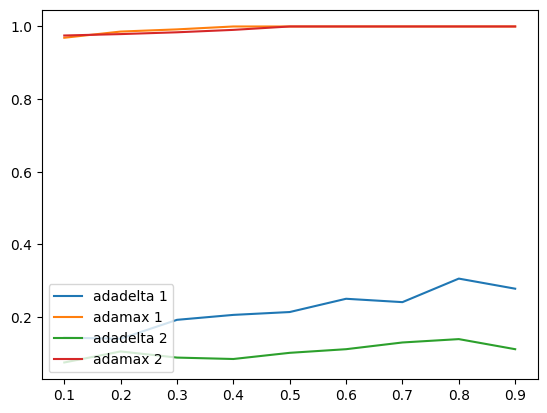

In [148]:
plot(arange(0.1, 1.0, step=0.1), sz_dep0["test_accuracy"], label="adadelta 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep1["test_accuracy"], label="adamax 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep2["test_accuracy"], label="adadelta 2")
plot(arange(0.1, 1.0, step=0.1), sz_dep3["test_accuracy"], label="adamax 2")
legend(loc="lower left")

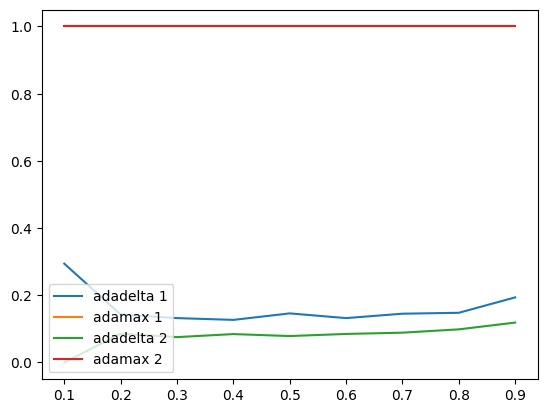

In [149]:
plot(arange(0.1, 1.0, step=0.1), sz_dep0["train_accuracy"], label="adadelta 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep1["train_accuracy"], label="adamax 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep2["train_accuracy"], label="adadelta 2")
plot(arange(0.1, 1.0, step=0.1), sz_dep3["train_accuracy"], label="adamax 2")
legend(loc="lower left")

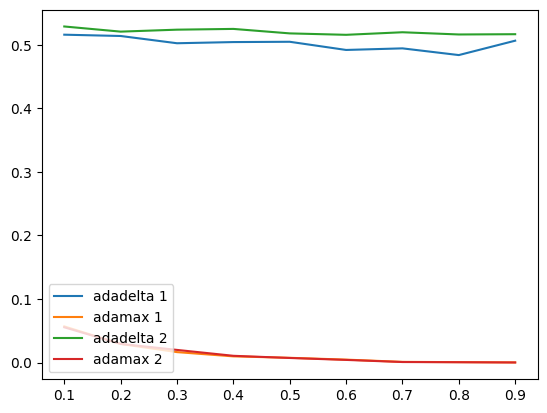

In [150]:
plot(arange(0.1, 1.0, step=0.1), sz_dep0["test_loss"], label="adadelta 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep1["test_loss"], label="adamax 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep2["test_loss"], label="adadelta 2")
plot(arange(0.1, 1.0, step=0.1), sz_dep3["test_loss"], label="adamax 2")
legend(loc="lower left")

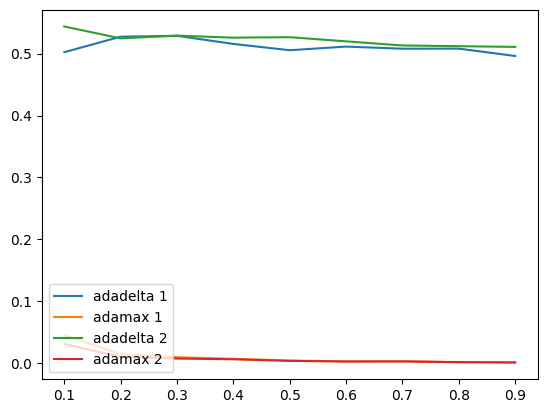

In [151]:
plot(arange(0.1, 1.0, step=0.1), sz_dep0["train_loss"], label="adadelta 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep1["train_loss"], label="adamax 1")
plot(arange(0.1, 1.0, step=0.1), sz_dep2["train_loss"], label="adadelta 2")
plot(arange(0.1, 1.0, step=0.1), sz_dep3["train_loss"], label="adamax 2")
legend(loc="lower left")

### Графики от количества эпох

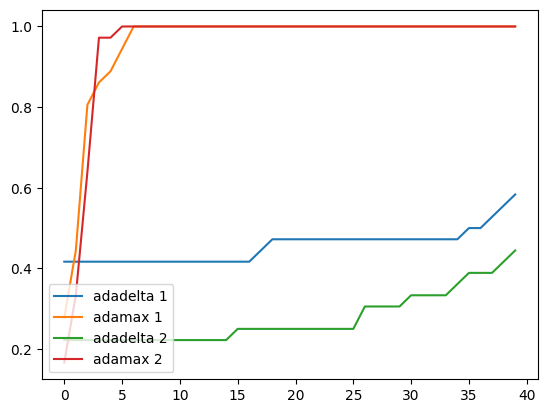

In [152]:
plot(range(EPOCHS), ep_dep0["test_accuracy"], label="adadelta 1")
plot(range(EPOCHS), ep_dep1["test_accuracy"], label="adamax 1")
plot(range(EPOCHS), ep_dep2["test_accuracy"], label="adadelta 2")
plot(range(EPOCHS), ep_dep3["test_accuracy"], label="adamax 2")
legend(loc="lower left")

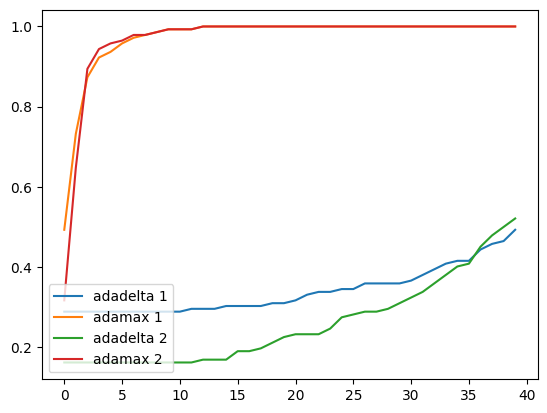

In [153]:
plot(range(EPOCHS), ep_dep0["train_accuracy"], label="adadelta 1")
plot(range(EPOCHS), ep_dep1["train_accuracy"], label="adamax 1")
plot(range(EPOCHS), ep_dep2["train_accuracy"], label="adadelta 2")
plot(range(EPOCHS), ep_dep3["train_accuracy"], label="adamax 2")
legend(loc="lower left")

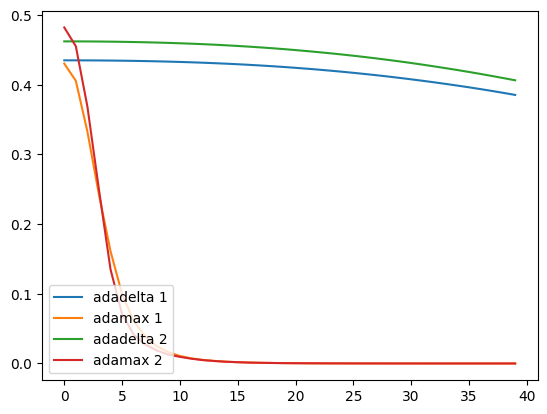

In [154]:
plot(range(EPOCHS), ep_dep0["test_loss"], label="adadelta 1")
plot(range(EPOCHS), ep_dep1["test_loss"], label="adamax 1")
plot(range(EPOCHS), ep_dep2["test_loss"], label="adadelta 2")
plot(range(EPOCHS), ep_dep3["test_loss"], label="adamax 2")
legend(loc="lower left")

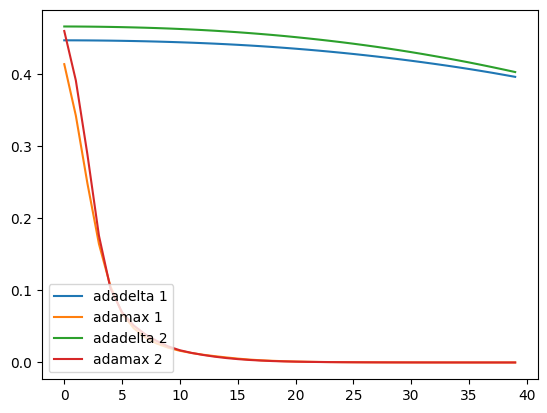

In [155]:
plot(range(EPOCHS), ep_dep0["train_loss"], label="adadelta 1")
plot(range(EPOCHS), ep_dep1["train_loss"], label="adamax 1")
plot(range(EPOCHS), ep_dep2["train_loss"], label="adadelta 2")
plot(range(EPOCHS), ep_dep3["train_loss"], label="adamax 2")
legend(loc="lower left")

### Графики от dropout

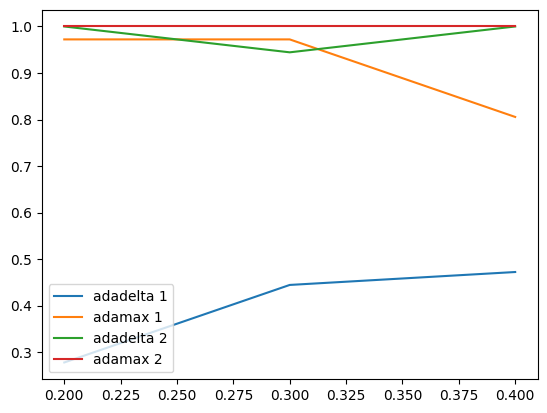

In [156]:
plot(arange(0.2, 0.5, step=0.1), dp_dep0["test_accuracy"], label="adadelta 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep1["test_accuracy"], label="adamax 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep2["test_accuracy"], label="adadelta 2")
plot(arange(0.2, 0.5, step=0.1), dp_dep3["test_accuracy"], label="adamax 2")
legend(loc="lower left")

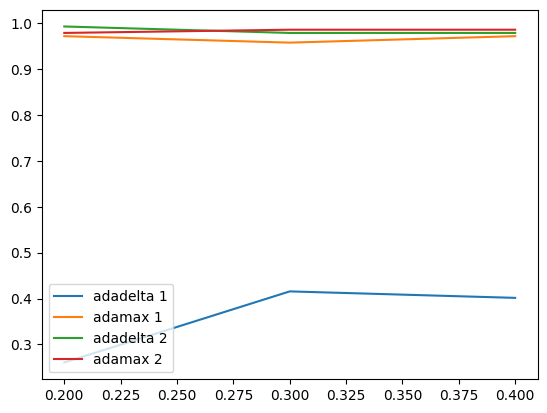

In [157]:
plot(arange(0.2, 0.5, step=0.1), dp_dep0["train_accuracy"], label="adadelta 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep1["train_accuracy"], label="adamax 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep2["train_accuracy"], label="adadelta 2")
plot(arange(0.2, 0.5, step=0.1), dp_dep3["train_accuracy"], label="adamax 2")
legend(loc="lower left")

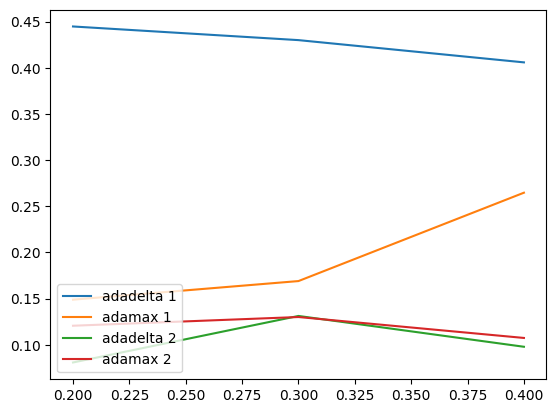

In [158]:
plot(arange(0.2, 0.5, step=0.1), dp_dep0["test_loss"], label="adadelta 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep1["test_loss"], label="adamax 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep2["test_loss"], label="adadelta 2")
plot(arange(0.2, 0.5, step=0.1), dp_dep3["test_loss"], label="adamax 2")
legend(loc="lower left")

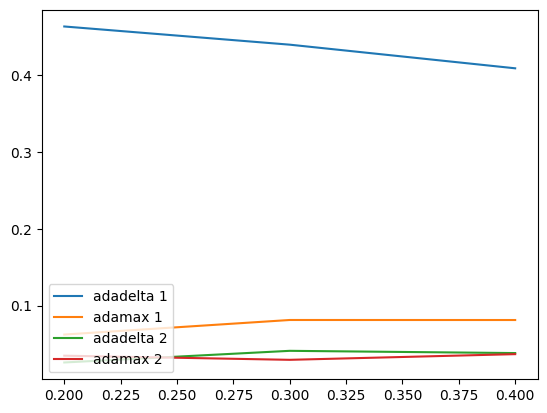

In [159]:
plot(arange(0.2, 0.5, step=0.1), dp_dep0["train_loss"], label="adadelta 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep1["train_loss"], label="adamax 1")
plot(arange(0.2, 0.5, step=0.1), dp_dep2["train_loss"], label="adadelta 2")
plot(arange(0.2, 0.5, step=0.1), dp_dep3["train_loss"], label="adamax 2")
legend(loc="lower left")

## Пункт 10.
Рассчитать метрики precision, recall, TPN, FPN, F1

### Получаем значения метрик

In [160]:
loss0, accuracy0, prec0, recall0, tpn0, fpn0 = DELTA1.evaluate(test_x, test_y)
loss1, accuracy1, prec1, recall1, tpn1, fpn1 = MAX1.evaluate(test_x, test_y)
loss2, accuracy2, prec2, recall2, tpn2, fpn2 = DELTA2.evaluate(test_x, test_y)
loss3, accuracy3, prec3, recall3, tpn3, fpn3 = MAX2.evaluate(test_x, test_y)

2/2 [==============================] - 0s 5ms/step - loss: 0.0190 - categorical_accuracy: 0.9722 - precision_4: 0.9722 - recall_4: 0.9722 - true_positives_4: 35.0000 - false_positives_4: 1.0000


### Выводим полученные метрики

In [161]:
print(f"""
adadelta 1:
    loss: {loss0}
    accuracy: {accuracy0}
    precision: {prec0}
    recall: {recall0}
    tpn: {tpn0}
    fpn: {fpn0}
    f1: {f1(prec0, recall0)}
adamax 1:
    loss: {loss1}
    accuracy: {accuracy1}
    precision: {prec1}
    recall: {recall1}
    tpn: {tpn1}
    fpn: {fpn1}
    f1: {f1(prec1, recall1)}
adadelta 2:
    loss: {loss2}
    accuracy: {accuracy2}
    precision: {prec2}
    recall: {recall2}
    tpn: {tpn2}
    fpn: {fpn2}
    f1: {f1(prec2, recall2)}
adamax 2:
    loss: {loss3}
    accuracy: {accuracy3}
    precision: {prec3}
    recall: {recall3}
    tpn: {tpn3}
    fpn: {fpn3}
    f1: {f1(prec3, recall3)}
""")


adadelta 1:
    loss: 0.41130387783050537
    accuracy: 0.5
    precision: 0.4285714328289032
    recall: 0.1666666716337204
    tpn: 6.0
    fpn: 8.0
    f1: 0.24000000581741332
adamax 1:
    loss: 0.07814803719520569
    accuracy: 0.9722222089767456
    precision: 0.9722222089767456
    recall: 0.9722222089767456
    tpn: 35.0
    fpn: 1.0
    f1: 0.9722222089767456
adadelta 2:
    loss: 0.434565007686615
    accuracy: 0.3333333432674408
    precision: 0.3333333432674408
    recall: 0.1111111119389534
    tpn: 4.0
    fpn: 8.0
    f1: 0.16666666883975265
adamax 2:
    loss: 0.019017953425645828
    accuracy: 0.9722222089767456
    precision: 0.9722222089767456
    recall: 0.9722222089767456
    tpn: 35.0
    fpn: 1.0
    f1: 0.9722222089767456



## Пункт 11.
    Построить ROC кривые и посчитать площадь AUC под кривой

C:\Users\seva-\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

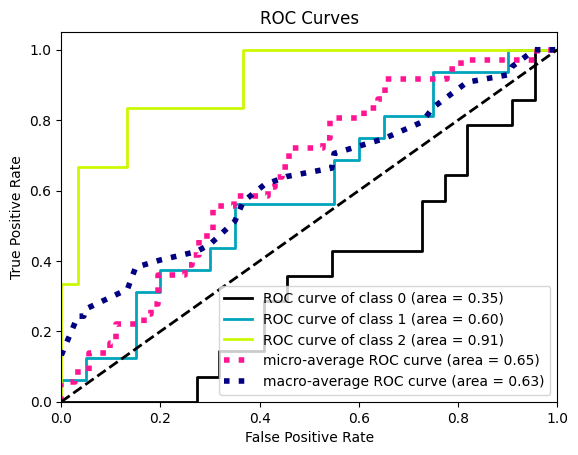

In [162]:
plot_roc_curve(test_y.argmax(axis=1), p0)

C:\Users\seva-\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

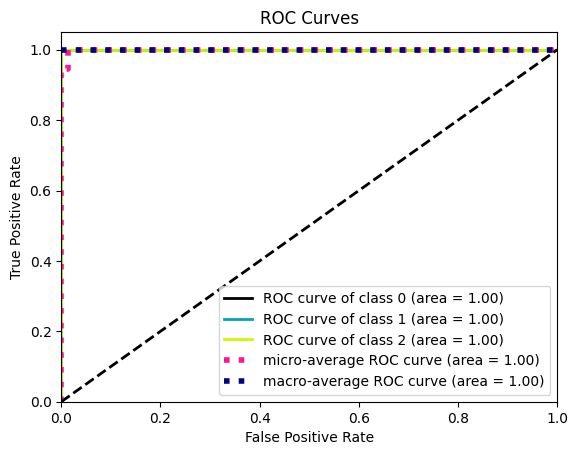

In [163]:
plot_roc_curve(test_y.argmax(axis=1), p1)

C:\Users\seva-\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

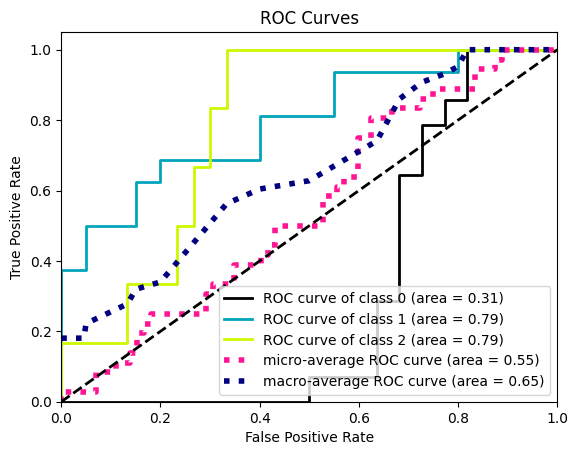

In [164]:
plot_roc_curve(test_y.argmax(axis=1), p2)

C:\Users\seva-\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


<Axes: title={'center': 'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

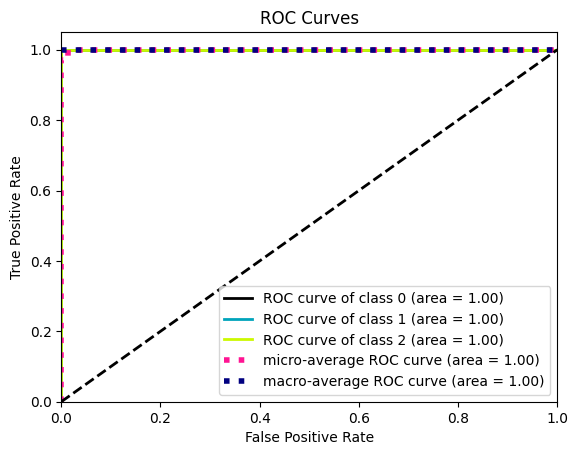

In [165]:
plot_roc_curve(test_y.argmax(axis=1), p3)

## Пункт 12.
    Рассчитать и построить графическое изображение для Confusion matrics.

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

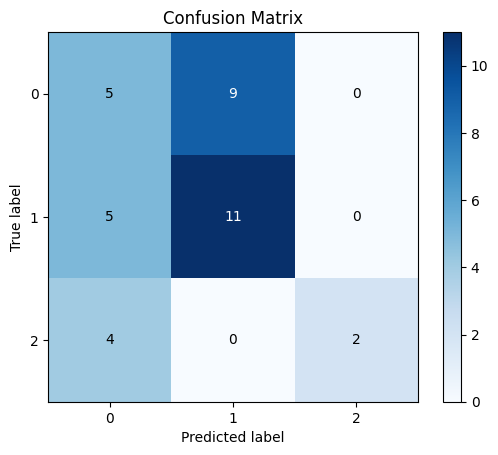

In [166]:
plot_confusion_matrix(test_y.argmax(axis=1), p0.argmax(axis=1))

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

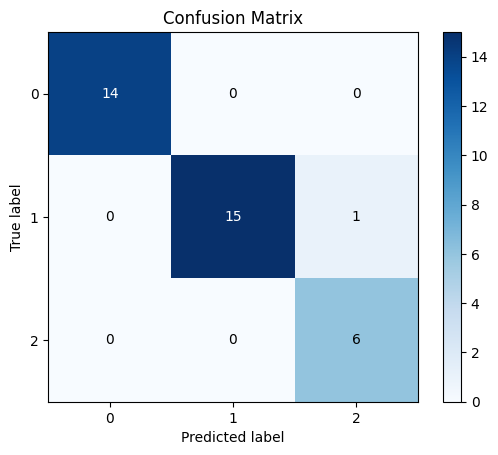

In [167]:
plot_confusion_matrix(test_y.argmax(axis=1), p1.argmax(axis=1))

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

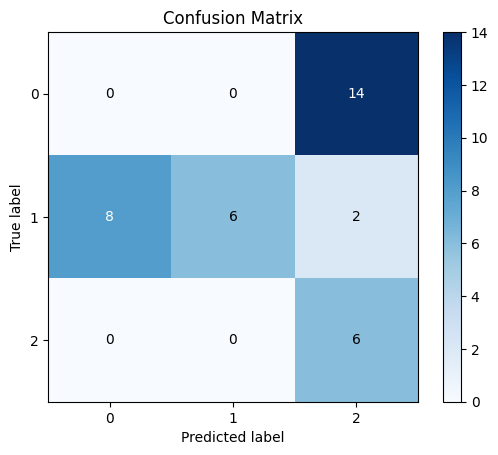

In [168]:
plot_confusion_matrix(test_y.argmax(axis=1), p2.argmax(axis=1))

<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

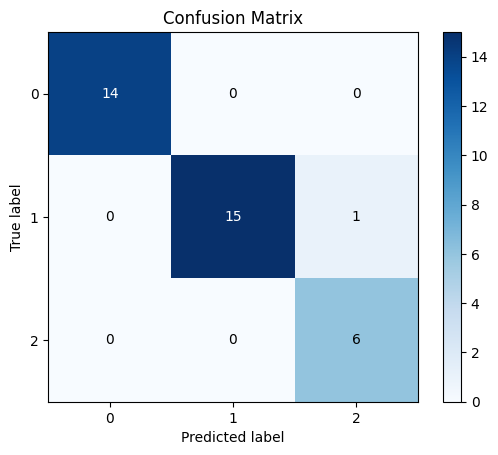

In [169]:
plot_confusion_matrix(test_y.argmax(axis=1), p3.argmax(axis=1))

## Пункт 13.

### Вывод
Исходя из полученных результатов, лучшей моделью является модель с двумя скрытыми слоями, обученная алгоритмом Adamax